# **Fake Job Posting Detector**


In [4]:
# Step 1: Upload the CSV file
from google.colab import files


# Step 2: Import pandas
import pandas as pd


df = pd.read_csv('fake_job_postings.csv')


df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [6]:
# Colab cell 2 — Imports
import os
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)


In [7]:
# Colab cell 3 — Load dataset (upload or path)
from google.colab import files
# Use this to interactively upload if needed:
# uploaded = files.upload()

df = pd.read_csv("/content/fake_job_postings.csv")   # change path if needed
print(df.info())
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [8]:
# Colab cell 4 — Quick EDA
print("Total rows:", len(df))
print("Fraudulent distribution:\n", df['fraudulent'].value_counts(normalize=False))
print("\nSample titles:")
display(df[['job_id','title','fraudulent']].head(8))


Total rows: 17880
Fraudulent distribution:
 fraudulent
0    17014
1      866
Name: count, dtype: int64

Sample titles:


,job_id,title,fraudulent
0,1,Marketing Intern,0
1,2,Customer Service - Cloud Video Production,0
2,3,Commissioning Machinery Assistant (CMA),0
3,4,Account Executive - Washington DC,0
4,5,Bill Review Manager,0
5,6,Accounting Clerk,0
6,7,Head of Content (m/f),0
7,8,Lead Guest Service Specialist,0


In [9]:
# Colab cell 5 — Text cleaning helper and combine text fields
def clean_text(s):
    if pd.isna(s):
        return ""
    s = str(s)
    s = s.replace('\n',' ').replace('\r',' ')
    s = re.sub(r"http\S+|www\S+"," ", s)        # remove urls
    s = re.sub(r"[^0-9A-Za-z.,!?;:'\"%()\- ]+", " ", s)  # keep most punctuation and letters
    s = re.sub(r"\s+", " ", s)                 # collapse whitespace
    return s.strip()

# Choose which text columns to combine (feel free to change)
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
for c in text_cols:
    if c not in df.columns:
        df[c] = ""

# Create combined text field (title given slightly more weight by repeating)
df['text'] = (
    df['title'].fillna("") + " . " +
    df['company_profile'].fillna("") + " . " +
    df['description'].fillna("") + " . " +
    df['requirements'].fillna("") + " . " +
    df['benefits'].fillna("")
).map(clean_text)

# Confirm
df[['job_id','title','fraudulent','text']].head(3)


,job_id,title,fraudulent,text
0,1,Marketing Intern,0,"Marketing Intern . We're Food52, and we've cre..."
1,2,Customer Service - Cloud Video Production,0,Customer Service - Cloud Video Production . 90...
2,3,Commissioning Machinery Assistant (CMA),0,Commissioning Machinery Assistant (CMA) . Valo...


In [10]:
# Colab cell 6 — Prepare X, y and train/test split
X = df['text'].values
y = df['fraudulent'].values   # 0 = real, 1 = fake

# Stratified split to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
print("Train size:", len(X_train), "Test size:", len(X_test))
print("Train fraudulent dist:", np.bincount(y_train))
print("Test fraudulent dist:", np.bincount(y_test))


Train size: 15198 Test size: 2682
Train fraudulent dist: [14462   736]
Test fraudulent dist: [2552  130]


In [11]:
# Colab cell 7 — Build TF-IDF vectorizer and model pipelines
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2),
    stop_words='english'
)

# Logistic Regression with class weight to handle imbalance
pipe_lr = make_pipeline(
    tfidf,
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
)

# Random Forest with class_weight balanced
pipe_rf = make_pipeline(
    tfidf,
    RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
)


In [12]:
# Colab cell 8 — Train models
print("Training Logistic Regression...")
pipe_lr.fit(X_train, y_train)
print("Training Random Forest...")
pipe_rf.fit(X_train, y_train)
print("Training complete.")


Training Logistic Regression...
Training Random Forest...
Training complete.


In [13]:
# Colab cell 9 — Evaluation helper
def evaluate(pipe, X_test, y_test, name="Model"):
    preds = pipe.predict(X_test)
    probs = None
    try:
        probs = pipe.predict_proba(X_test)[:,1]
    except:
        pass

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    auc = roc_auc_score(y_test, probs) if probs is not None else None

    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    if auc is not None:
        print(f"ROC AUC: {auc:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, preds, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
    return {'preds': preds, 'probs': probs}

res_lr = evaluate(pipe_lr, X_test, y_test, "Logistic Regression")
res_rf = evaluate(pipe_rf, X_test, y_test, "Random Forest")


=== Logistic Regression ===
Accuracy: 0.9836
Precision: 0.7867
Recall: 0.9077
F1-score: 0.8429
ROC AUC: 0.9859

Classification Report:
               precision    recall  f1-score   support

           0     0.9953    0.9875    0.9913      2552
           1     0.7867    0.9077    0.8429       130

    accuracy                         0.9836      2682
   macro avg     0.8910    0.9476    0.9171      2682
weighted avg     0.9851    0.9836    0.9841      2682

Confusion Matrix:
 [[2520   32]
 [  12  118]]
=== Random Forest ===
Accuracy: 0.9821
Precision: 0.9881
Recall: 0.6385
F1-score: 0.7757
ROC AUC: 0.9902

Classification Report:
               precision    recall  f1-score   support

           0     0.9819    0.9996    0.9907      2552
           1     0.9881    0.6385    0.7757       130

    accuracy                         0.9821      2682
   macro avg     0.9850    0.8190    0.8832      2682
weighted avg     0.9822    0.9821    0.9803      2682

Confusion Matrix:
 [[2551    1]
 [

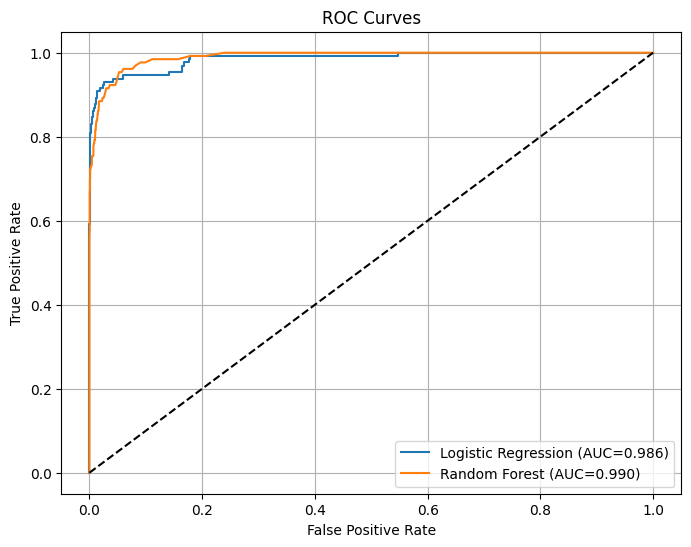

In [14]:
# Colab cell 10 — Plot ROC curves (if probability available)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
for res, label in [(res_lr, "Logistic Regression"), (res_rf, "Random Forest")]:
    if res['probs'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['probs'])
        auc = roc_auc_score(y_test, res['probs'])
        plt.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
# Colab cell 11 — Save trained pipelines (TF-IDF included)
os.makedirs("models", exist_ok=True)
joblib.dump(pipe_lr, "models/pipe_logreg_tfidf.joblib")
joblib.dump(pipe_rf, "models/pipe_rf_tfidf.joblib")
print("Saved models to /content/models/")


Saved models to /content/models/


In [16]:
# Colab cell 12 — Quick inference demo with the logistic model
examples = [
    "Marketing Intern - Earn $5000/week! No experience required. Click here.",
    "Senior Data Scientist required. PhD in Statistics and 5+ years in ML. Full-time, benefits included."
]
for e in examples:
    p = pipe_lr.predict([e])[0]
    proba = pipe_lr.predict_proba([e])[0][1] if hasattr(pipe_lr[-1],"predict_proba") or hasattr(pipe_lr,"predict_proba") else None
    print("---")
    print(e)
    print("Predicted fraudulent:", int(p), " (1=fake, 0=real)")
    if proba is not None:
        print("Probability of fake:", proba)


---
Marketing Intern - Earn $5000/week! No experience required. Click here.
Predicted fraudulent: 1  (1=fake, 0=real)
Probability of fake: 0.595290578527933
---
Senior Data Scientist required. PhD in Statistics and 5+ years in ML. Full-time, benefits included.
Predicted fraudulent: 0  (1=fake, 0=real)
Probability of fake: 0.32142411841272267


**Testing**

In [17]:
# Fake Job Posting Model Evaluation


!pip install -q scikit-learn pandas joblib matplotlib seaborn


import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Load the labeled test dataset
df = pd.read_csv("test_jobs_labeled_1000.csv")
print("Dataset loaded successfully!")
print(df.shape)
df.head()


Dataset loaded successfully!
(1000, 6)


,title,company_profile,description,requirements,benefits,fraudulent
0,Senior Backend Developer,SaaS company delivering security and identity ...,"Develop scalable backend services, own microse...","Experience with CI/CD tools, Docker, and monit...","Training and development programs, annual bonu...",0
1,Network Administrator,HR & recruitment consultancy with regional off...,Research and implement machine learning models...,"Experience with CI/CD tools, Docker, and monit...","Competitive salary, relocation assistance, and...",0
2,Mobile App Developer,Enterprise software company providing solution...,"Resolve customer queries via email and chat, m...",Proven marketing experience with digital chann...,"Stock options, health coverage, remote-friendl...",0
3,Machine Learning Engineer,Customer-first fintech company simplifying pay...,"Resolve customer queries via email and chat, m...",Strong programming skills in Java/Python; expe...,"Paid vacation, retirement plan, and health ins...",0
4,Software Engineer,Global marketing agency working with enterpris...,"Lead marketing campaigns across channels, anal...","Experience with CI/CD tools, Docker, and monit...","Generous leave policy, health benefits, and re...",0


In [18]:
df["text"] = (
    df["title"].fillna('') + " . " +
    df["company_profile"].fillna('') + " . " +
    df["description"].fillna('') + " . " +
    df["requirements"].fillna('') + " . " +
    df["benefits"].fillna('')
)

X_test = df["text"]
y_test = df["fraudulent"]

model_lr = joblib.load("models/pipe_logreg_tfidf.joblib")
model_rf = joblib.load("models/pipe_rf_tfidf.joblib")

In [19]:
pred_lr = model_lr.predict(X_test)
pred_rf = model_rf.predict(X_test)

# Evaluate both models
def evaluate_model(name, y_true, y_pred):
    print(f"\n===== {name} =====")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-Score :", f1_score(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


===== Logistic Regression =====
Accuracy : 0.931
Precision: 1.0
Recall   : 0.8028571428571428
F1-Score : 0.8906497622820919

Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       650
           1       1.00      0.80      0.89       350

    accuracy                           0.93      1000
   macro avg       0.95      0.90      0.92      1000
weighted avg       0.94      0.93      0.93      1000



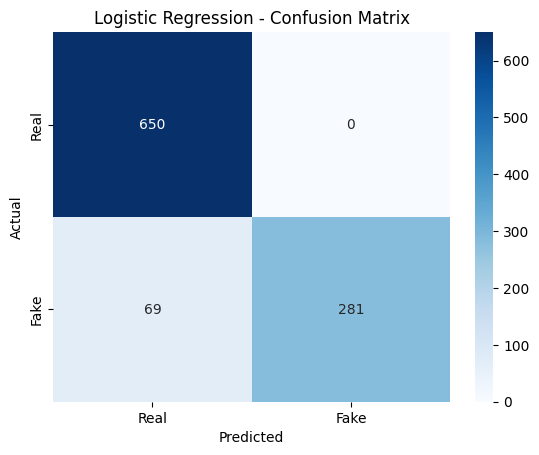

In [20]:
evaluate_model("Logistic Regression", y_test, pred_lr)


===== Random Forest =====
Accuracy : 0.729
Precision: 1.0
Recall   : 0.2257142857142857
F1-Score : 0.3682983682983683

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83       650
           1       1.00      0.23      0.37       350

    accuracy                           0.73      1000
   macro avg       0.85      0.61      0.60      1000
weighted avg       0.81      0.73      0.67      1000



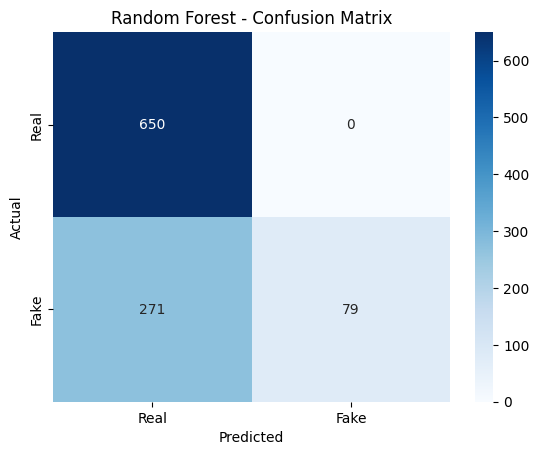

In [21]:
evaluate_model("Random Forest", y_test, pred_rf)

In [22]:
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

metrics_lr = get_metrics(y_test, pred_lr)
metrics_rf = get_metrics(y_test, pred_rf)

# Combine into DataFrame for comparison
metrics_df = pd.DataFrame([metrics_lr, metrics_rf],
                          index=["Logistic Regression", "Random Forest"])
print("\n📊 Model Performance Comparison:")
display(metrics_df)



📊 Model Performance Comparison:


,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.931,1.0,0.802857,0.890650
Random Forest,0.729,1.0,0.225714,0.368298


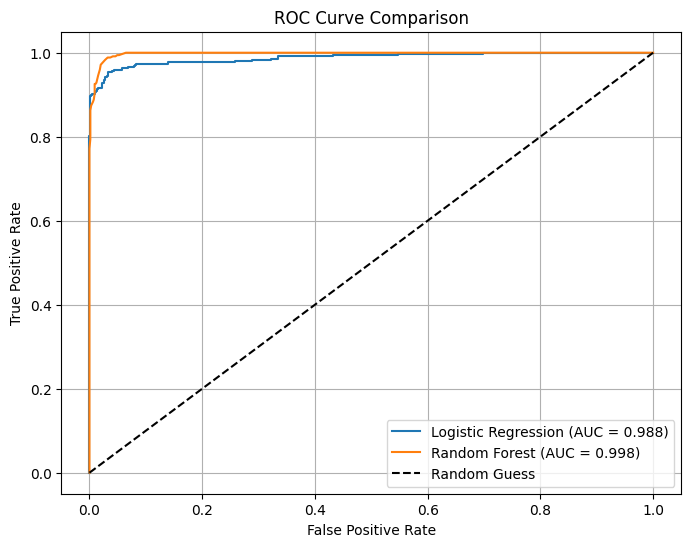

In [23]:
from sklearn.metrics import roc_curve, auc

try:
    prob_lr = model_lr.predict_proba(X_test)[:, 1]
    prob_rf = model_rf.predict_proba(X_test)[:, 1]
except:
    prob_lr = [0] * len(X_test)
    prob_rf = [0] * len(X_test)

fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)

auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


<Figure size 800x500 with 0 Axes>

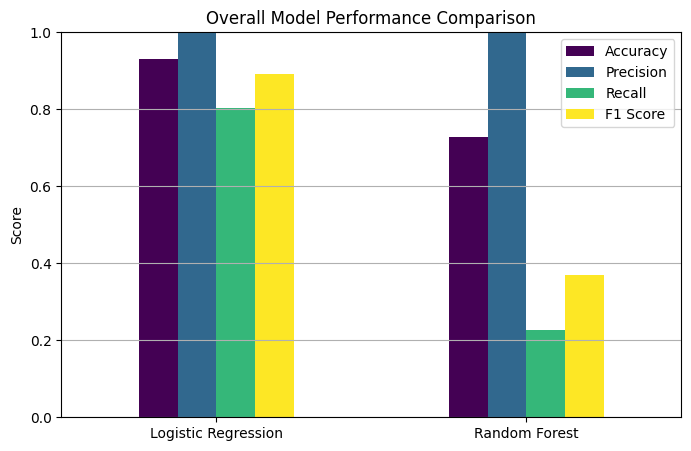


🏁 Based on F1-Score, the better performing model is: **Logistic Regression**


In [24]:
plt.figure(figsize=(8, 5))
metrics_df.plot(kind='bar', figsize=(8, 5), colormap='viridis', rot=0)
plt.title("Overall Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

#  Summary conclusion
better_model = "Random Forest" if metrics_rf["F1 Score"] > metrics_lr["F1 Score"] else "Logistic Regression"
print(f"\n🏁 Based on F1-Score, the better performing model is: **{better_model}**")

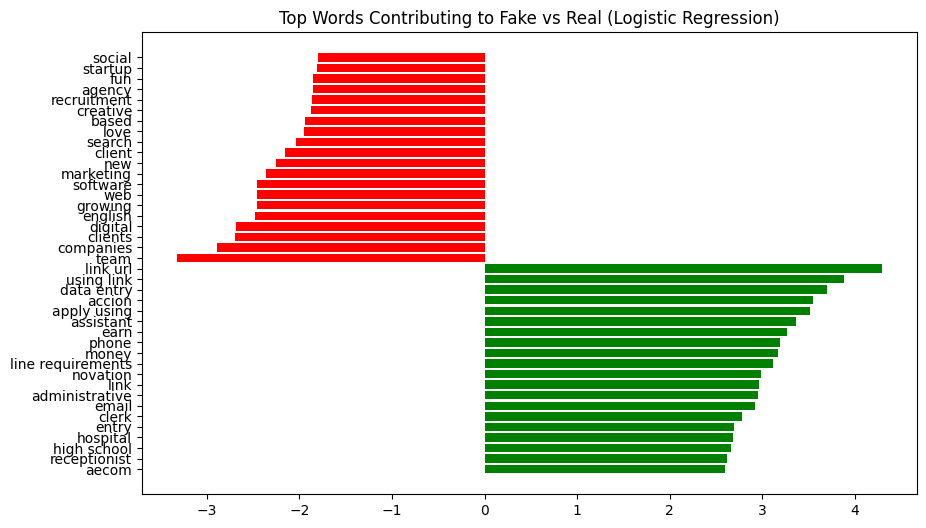

In [25]:
# Logistic Regression - Top features
import numpy as np

vectorizer = tfidf
model = pipe_lr.named_steps['logisticregression'] if 'logisticregression' in pipe_lr.named_steps else pipe_lr[-1]
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_positive_idx = np.argsort(coefficients)[-20:]
top_negative_idx = np.argsort(coefficients)[:20]

plt.figure(figsize=(10,6))
plt.barh([feature_names[i] for i in top_positive_idx], coefficients[top_positive_idx], color='green')
plt.barh([feature_names[i] for i in top_negative_idx], coefficients[top_negative_idx], color='red')
plt.title("Top Words Contributing to Fake vs Real (Logistic Regression)")
plt.show()


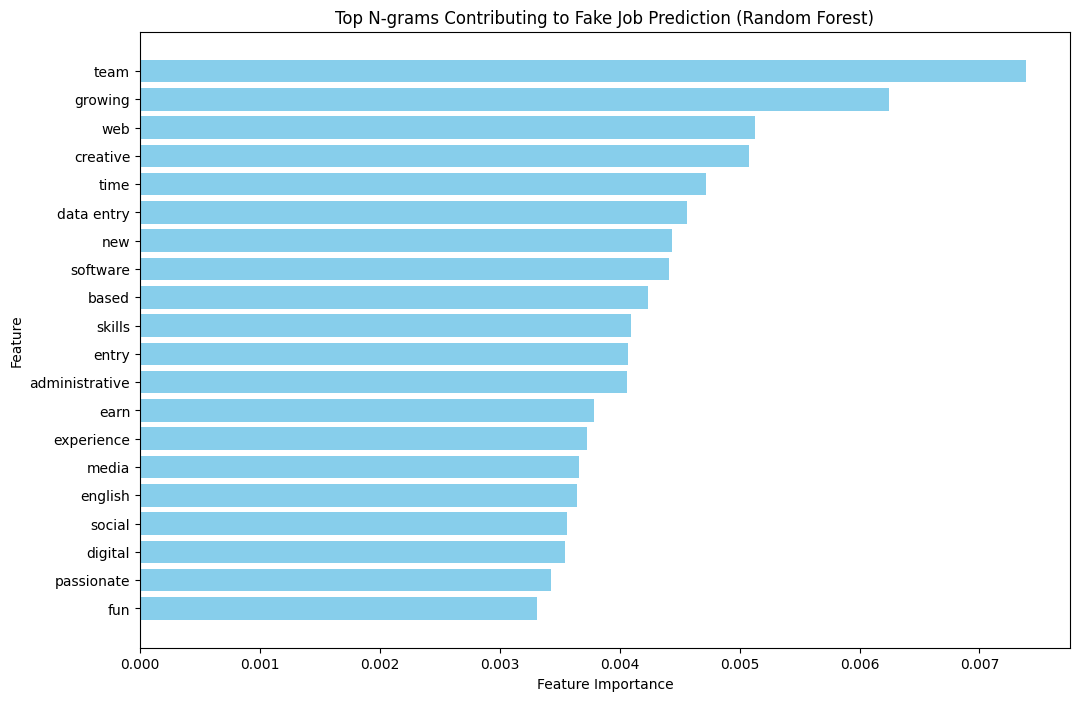

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Extract TF-IDF vectorizer and Random Forest model from the pipeline
vectorizer_rf = pipe_rf.named_steps['tfidfvectorizer']  # TF-IDF step in pipeline
model_rf = pipe_rf.named_steps['randomforestclassifier']  # Random Forest model

# Get feature names and importance scores
feature_names = vectorizer_rf.get_feature_names_out()
importances = model_rf.feature_importances_

# Select top 20 most important features
top_idx = np.argsort(importances)[-20:]

plt.figure(figsize=(12,8))
plt.barh([feature_names[i] for i in top_idx], importances[top_idx], color='skyblue')
plt.title("Top N-grams Contributing to Fake Job Prediction (Random Forest)")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()


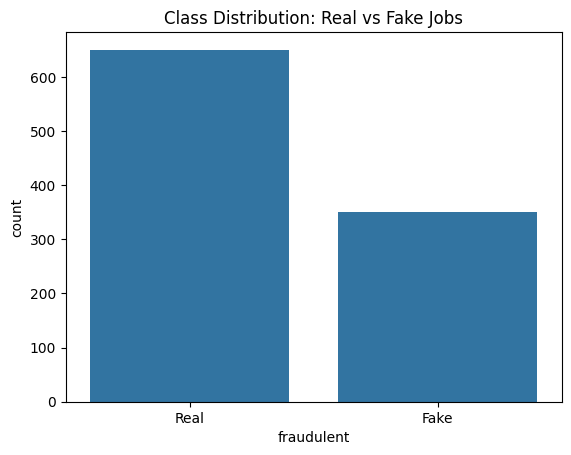

In [26]:
sns.countplot(x='fraudulent', data=df)
plt.title("Class Distribution: Real vs Fake Jobs")
plt.xticks([0,1], ['Real', 'Fake'])
plt.show()
